In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('./data/cleaned_disease_data.csv')
df.head()

,Country,Year,Status,Life_expectancy,Alcohol,Hepatitis_B,BMI,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling,Measles
0,Afghanistan,2000,0,54.8,0.01,62.0,12.2,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052,27.0
1,Afghanistan,2001,0,55.3,0.01,63.0,12.6,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551,37.0
2,Afghanistan,2002,0,56.2,0.01,64.0,13.0,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049,35.0
3,Afghanistan,2003,0,56.7,0.01,65.0,13.4,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548,39.0
4,Afghanistan,2004,0,57.0,0.02,95.0,13.8,95.0,95.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046,48.0


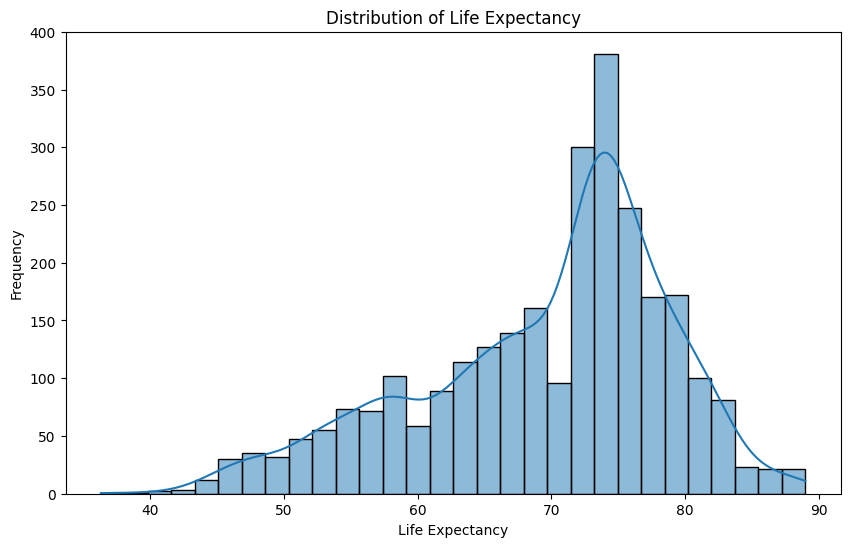

count    2766.000000
mean       69.576511
std         9.379059
min        36.300000
25%        63.900000
50%        72.400000
75%        75.800000
max        89.000000
Name: Life_expectancy, dtype: float64


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Life_expectancy'], kde=True, bins=30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

# 기대수명의 기술 통계량
print(df['Life_expectancy'].describe())

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2766 non-null   object 
 1   Year                  2766 non-null   int64  
 2   Status                2766 non-null   int64  
 3   Life_expectancy       2766 non-null   float64
 4   Alcohol               2766 non-null   float64
 5   Hepatitis_B           2766 non-null   float64
 6   BMI                   2766 non-null   float64
 7   Polio                 2766 non-null   float64
 8   Diphtheria            2766 non-null   float64
 9   HIV_AIDS              2766 non-null   float64
 10  GDP                   2766 non-null   float64
 11  thinness _1_19_years  2766 non-null   float64
 12  thinness_5_9_years    2766 non-null   float64
 13  Iso_code              2766 non-null   object 
 14  Region                2766 non-null   object 
 15  Region_encoded       

country, iso_code, region은 제거

In [6]:
X = df.drop('Life_expectancy', axis=1)
y = df['Life_expectancy']

drop_cols = ['Country', 'Iso_code', 'Region']
X = X.drop(columns=drop_cols)

print(X)
print(y)

      Year  Status  Alcohol  Hepatitis_B   BMI  Polio  Diphtheria  HIV_AIDS  \
0     2000       0     0.01         62.0  12.2   24.0        24.0       0.1   
1     2001       0     0.01         63.0  12.6   35.0        33.0       0.1   
2     2002       0     0.01         64.0  13.0   36.0        36.0       0.1   
3     2003       0     0.01         65.0  13.4   41.0        41.0       0.1   
4     2004       0     0.02         95.0  13.8   95.0        95.0       0.1   
...    ...     ...      ...          ...   ...    ...         ...       ...   
2761  2011       0     6.00         94.0  29.9   93.0        93.0      13.3   
2762  2012       0     6.09         97.0   3.3   95.0        95.0       8.8   
2763  2013       0     6.39         95.0   3.8   95.0        95.0       6.8   
2764  2014       0     6.50         91.0  31.3   92.0        91.0       6.3   
2765  2015       0     5.17         87.0  31.8   88.0        87.0       6.2   

             GDP  thinness _1_19_years  thinness_5_

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

In [9]:
# !pip install xgboost

In [10]:
import xgboost as xgb


# 기본 하이퍼파라미터로 우선 진행.
# 이후 하이퍼파라미터 튜닝을 이용해 최적값 찾기
model = xgb.XGBRegressor()

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=10)

[0]	validation_0-rmse:6.99646	validation_1-rmse:7.10244
[10]	validation_0-rmse:1.77874	validation_1-rmse:2.51705
[20]	validation_0-rmse:1.22833	validation_1-rmse:2.31457
[30]	validation_0-rmse:1.04541	validation_1-rmse:2.25474
[40]	validation_0-rmse:0.83586	validation_1-rmse:2.21061
[50]	validation_0-rmse:0.70928	validation_1-rmse:2.17822
[60]	validation_0-rmse:0.61748	validation_1-rmse:2.16978
[70]	validation_0-rmse:0.53875	validation_1-rmse:2.15930
[80]	validation_0-rmse:0.44473	validation_1-rmse:2.15351
[90]	validation_0-rmse:0.38937	validation_1-rmse:2.14104
[99]	validation_0-rmse:0.34335	validation_1-rmse:2.13120


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

평가

confusion matrix(ROC curve, AUC) -> classification에서 사용하는 방법이므로 생략  
기본 평가지표들 + cross validation 사용

In [11]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_squared_log_error, root_mean_squared_log_error, r2_score
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    msle = mean_squared_log_error(y_true, y_pred)
    rmsle = root_mean_squared_log_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MSLE': msle, 'RMSLE': rmsle, 'R2': r2}, name=name)

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_metrics = evaluate_model(y_train, y_train_pred, 'Train')
test_metrics = evaluate_model(y_test, y_test_pred, 'Test')

In [13]:
metrics_df = pd.DataFrame([train_metrics, test_metrics])
print(metrics_df.round(4))

          MSE    RMSE     MAE   MSLE   RMSLE      R2
Train  0.1179  0.3433  0.2385  0.000  0.0049  0.9987
Test   4.5420  2.1312  1.4409  0.001  0.0320  0.9484


시각화

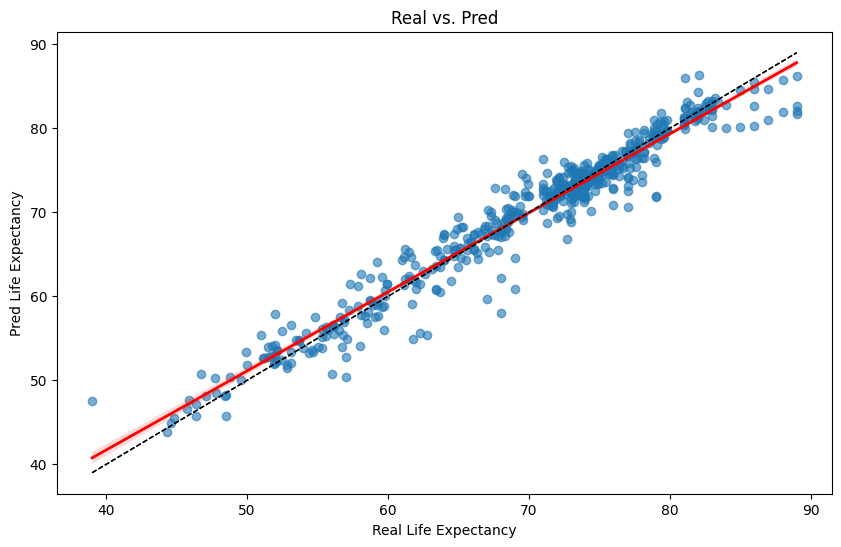

In [14]:

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_test_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'lw':2})

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
plt.xlabel("Real Life Expectancy")
plt.ylabel("Pred Life Expectancy")
plt.title("Real vs. Pred")
plt.show()

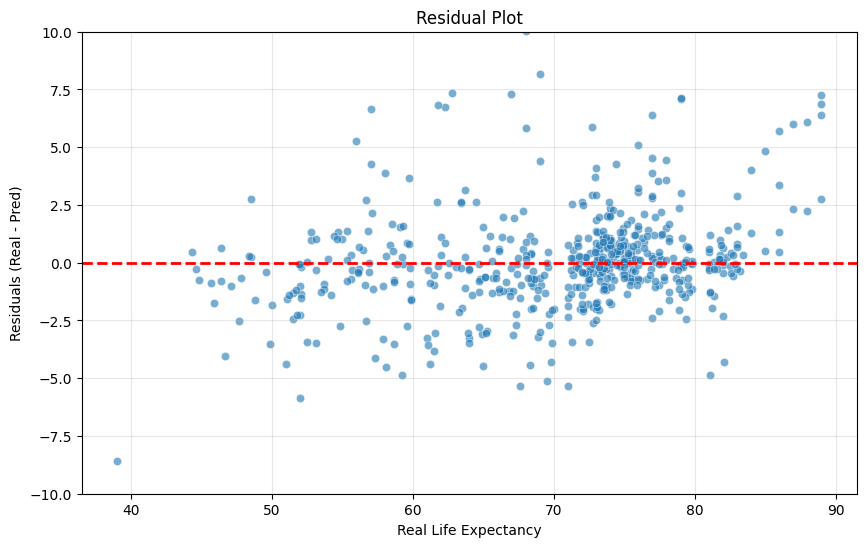

In [15]:
# 잔차를 직접 확인
# 0에 가까울 수록 좋음
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.ylim(-10, 10)
plt.xlabel("Real Life Expectancy")
plt.ylabel("Residuals (Real - Pred)")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()

하이퍼 파라미터 튜닝
(Optuna + K-Fold)

optuna가 선택한 각 하이퍼파라미터들을 kfold를 통해 교차검증 학습시킨다.  
직접적인 오차크기 측정을 위해 r2 보다는 MAE/MSE 쪽을 선택  
오차에 보다 민감한 MSE를 사용(나라/지역마다 상이하게 다른 feature를 보다 민감하게 수용하기 위함)  
RMSE가 MSE보다 직관적이기 떄문에 RMSE 사용

In [16]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [17]:
import optuna
from sklearn.model_selection import KFold

def objective(trial):
    param = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10, 1), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    fold_eval_results = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = xgb.XGBRegressor(**param)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
            verbose=False
        )

        fold_eval_results.append(model.evals_result())

        y_pred_fold = model.predict(X_val_fold)
        rmse = root_mean_squared_error(y_val_fold, y_pred_fold)
        rmse_scores.append(rmse)

    trial.set_user_attr('evals_results', fold_eval_results)

    
    return np.mean(rmse_scores)

In [18]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

[I 2026-02-10 06:34:00,000] A new study created in memory with name: no-name-2ec0bd0e-dc27-4f72-adba-14adab45c0f0
[I 2026-02-10 06:34:03,185] Trial 0 finished with value: 2.202818310621382 and parameters: {'n_estimators': 1600, 'learning_rate': 0.11848211841137862, 'max_depth': 10, 'colsample_bytree': 0.8123604344340587}. Best is trial 0 with value: 2.202818310621382.
[I 2026-02-10 06:34:08,421] Trial 1 finished with value: 2.1679552645860594 and parameters: {'n_estimators': 800, 'learning_rate': 0.046393154432252906, 'max_depth': 10, 'colsample_bytree': 0.5219042807174029}. Best is trial 1 with value: 2.1679552645860594.
[I 2026-02-10 06:34:08,824] Trial 2 finished with value: 2.3433720324313745 and parameters: {'n_estimators': 100, 'learning_rate': 0.07705969696198348, 'max_depth': 6, 'colsample_bytree': 0.9045658051299208}. Best is trial 1 with value: 2.1679552645860594.
[I 2026-02-10 06:34:11,364] Trial 3 finished with value: 2.2504543646539474 and parameters: {'n_estimators': 1400

In [19]:
best_params = study.best_params
best_rmse = study.best_value

print(f"최적의 하이퍼파라미터: {best_params}")
print(f"최저 교차 검증 RMSE: {best_rmse:.4f}")

최적의 하이퍼파라미터: {'n_estimators': 2000, 'learning_rate': 0.04804744132021147, 'max_depth': 8, 'colsample_bytree': 0.6709084499109006}
최저 교차 검증 RMSE: 2.0758


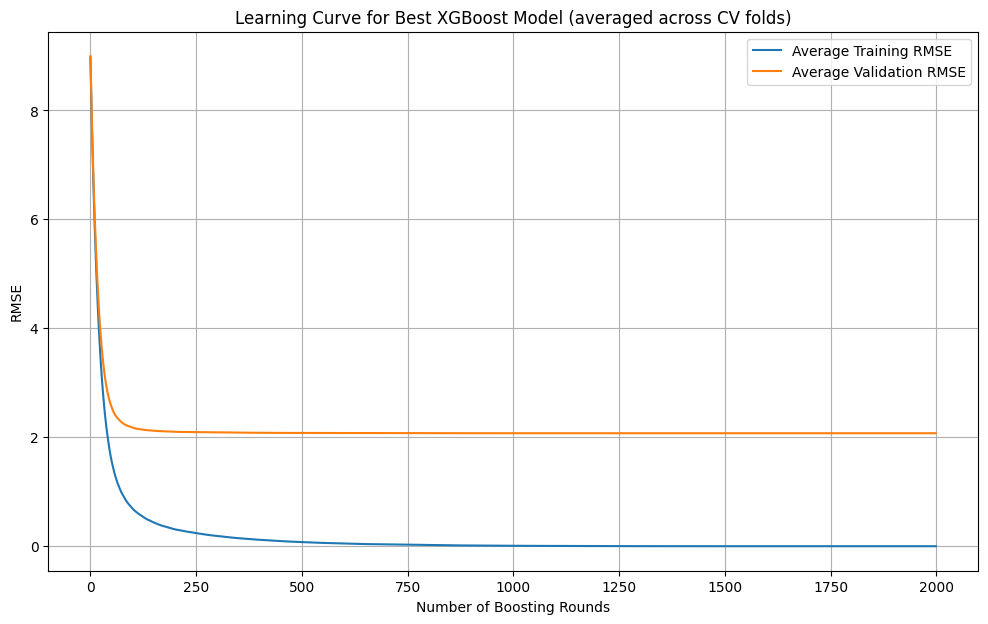

In [20]:
# 학습곡선 출력

best_trial = study.best_trial
evals_results_of_best_trial = best_trial.user_attrs['evals_results']

# 각 폴드별 학습 이력을 평균하여 전체 학습 곡선을 만듬
train_rmses_per_round = []
val_rmses_per_round = []


# n_estimators 라운드 수가 가변적, 가장 긴 이력에 맞춰 데이터를 처리
max_rounds = max([len(res['validation_0']['rmse']) for res in evals_results_of_best_trial])

for round_num in range(max_rounds):
    current_round_train_rmses = []
    current_round_val_rmses = []
    for fold_res in evals_results_of_best_trial:
        if round_num < len(fold_res['validation_0']['rmse']):
            current_round_train_rmses.append(fold_res['validation_0']['rmse'][round_num])
            current_round_val_rmses.append(fold_res['validation_1']['rmse'][round_num])
    if current_round_train_rmses:
        train_rmses_per_round.append(np.mean(current_round_train_rmses))
        val_rmses_per_round.append(np.mean(current_round_val_rmses))


# 시각화
plt.figure(figsize=(12, 7))
plt.plot(train_rmses_per_round, label='Average Training RMSE')
plt.plot(val_rmses_per_round, label='Average Validation RMSE')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve for Best XGBoost Model (averaged across CV folds)')
plt.legend()
plt.grid(True)
plt.show()

최적의 파라미터로 학습

In [21]:
for param, value in best_params.items():
    print(f"- {param}: {value}")

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train, verbose=50)


- n_estimators: 2000
- learning_rate: 0.04804744132021147
- max_depth: 8
- colsample_bytree: 0.6709084499109006


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6709084499109006
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [22]:
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_metrics = evaluate_model(y_train, y_train_pred, 'Train')
test_metrics = evaluate_model(y_test, y_test_pred, 'Test')

In [23]:
metrics_df = pd.DataFrame([train_metrics, test_metrics])
print(metrics_df.round(4))

          MSE    RMSE     MAE   MSLE   RMSLE      R2
Train  0.0000  0.0026  0.0017  0.000  0.0000  1.0000
Test   3.9963  1.9991  1.2539  0.001  0.0311  0.9546


시각화

점들이 검은색 점선에 가깝게 분포하고, 빨간색 회귀선이 검은색 점선과 일치할수록 모델의 예측 성능이 우수

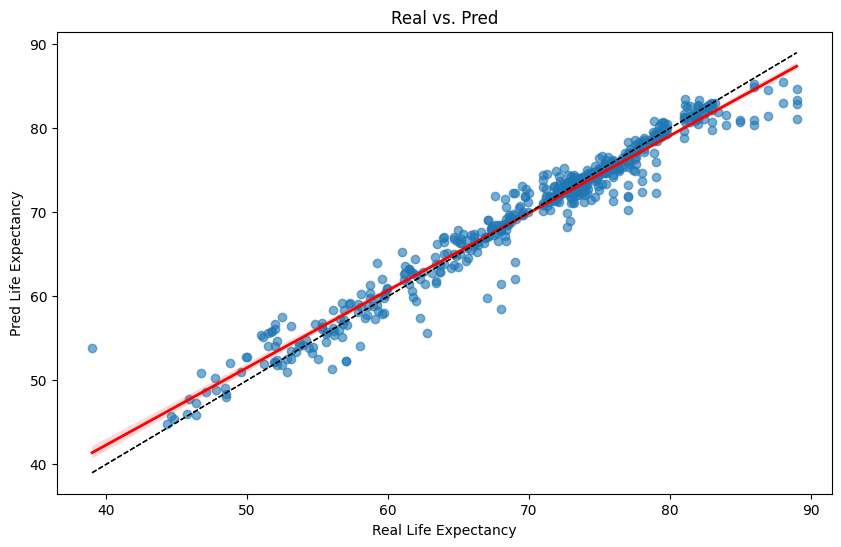

In [24]:

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_test_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'lw':2})

plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
plt.xlabel("Real Life Expectancy")
plt.ylabel("Pred Life Expectancy")
plt.title("Real vs. Pred")
plt.show()

In [25]:
metrics_df = pd.DataFrame([train_metrics, test_metrics])
print(metrics_df.round(4))

          MSE    RMSE     MAE   MSLE   RMSLE      R2
Train  0.0000  0.0026  0.0017  0.000  0.0000  1.0000
Test   3.9963  1.9991  1.2539  0.001  0.0311  0.9546


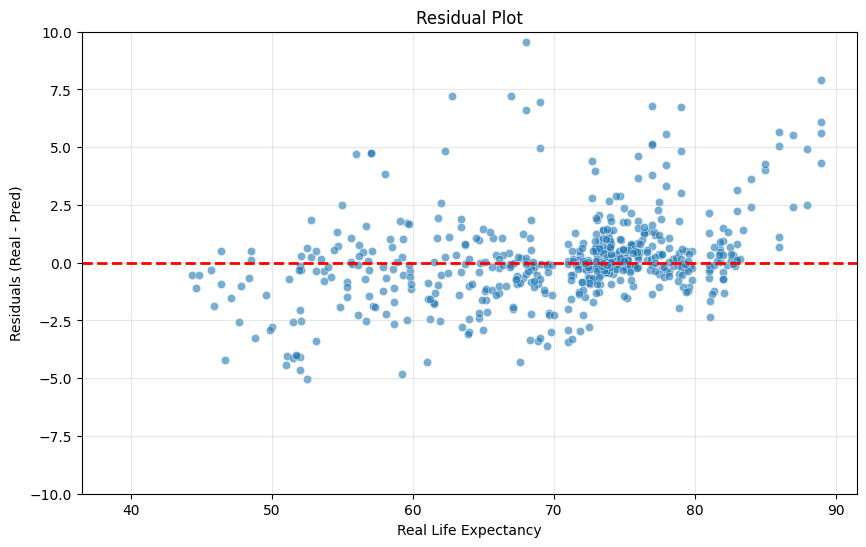

In [26]:
# 잔차를 직접 확인
# 0에 가까울 수록 좋음
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.ylim(-10, 10)
plt.xlabel("Real Life Expectancy")
plt.ylabel("Residuals (Real - Pred)")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()

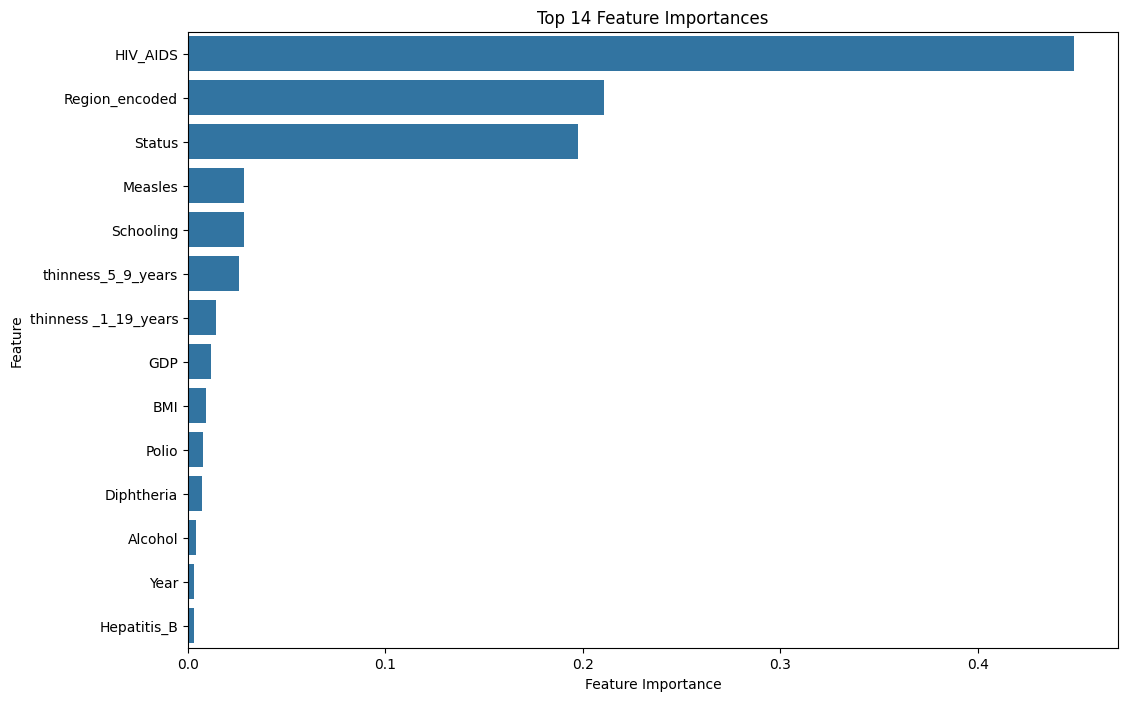

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


feature_importances = final_model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 상위 N개 피처 시각화
n_top_features = min(15, len(importance_df))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(n_top_features))
plt.title(f'Top {n_top_features} Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

테스트셋 하나 불러와서 실제 예측 실행

In [28]:
idx = 5 # X_test에서 불러올 인덱스

sample_data = X_test[idx].reshape(1, -1)

real_val = y_test.iloc[idx]
pred_val = final_model.predict(sample_data)[0]

print(f"--- 샘플 예측 결과 ---")
print(f"실제 기대수명: {real_val:.2f}")
print(f"예측 기대수명: {pred_val:.2f}")
print(f"오차(Difference): {abs(real_val - pred_val):.2f}")

--- 샘플 예측 결과 ---
실제 기대수명: 82.00
예측 기대수명: 80.51
오차(Difference): 1.49


모델, scaler 저장

In [ ]:
import joblib

# 모델과 스케일러 저장
joblib.dump(final_model, 'xgboost_life_model.pkl')
joblib.dump(std_scaler, 'scaler.pkl')

